# 02 — Analysis

Loads experiment data from Google Drive and runs all analyses.

**Run `01_run_experiment.ipynb` first** to generate `data_MODEL_DATE.csv` files.

## 1. Setup

In [15]:
# Clone repo (if not already done in this session)
!git clone https://github.com/auertobias/authority-bias-llm.git 2>/dev/null || echo "Already cloned"
%cd authority-bias-llm

from google.colab import drive
drive.mount('/content/drive')

/content/authority-bias-llm/authority-bias-llm
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!pip install -q statsmodels

import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sys.path.insert(0, '.')
from src.config import DATA_PATH, RESULTS_PATH

os.makedirs(RESULTS_PATH, exist_ok=True)
print(f"Reading data from: {DATA_PATH}")
print(f"Saving results to: {RESULTS_PATH}")

Reading data from: /content/drive/MyDrive/PhD/2PhD 1Paper/data/
Saving results to: /content/drive/MyDrive/PhD/2PhD 1Paper/results/


## 2. Load Data
Automatically finds and combines all `data_MODEL_DATE.csv` files.

In [17]:
data_files = sorted(glob.glob(DATA_PATH + "data_*.csv"))

if not data_files:
    raise FileNotFoundError(
        f"No data files found in {DATA_PATH}\n"
        "Run 01_run_experiment.ipynb first."
    )

print(f"Found {len(data_files)} file(s):")
dfs = []
for f in data_files:
    tmp = pd.read_csv(f)
    dfs.append(tmp)
    print(f"  {os.path.basename(f):40s} {len(tmp)} rows")

df_raw = pd.concat(dfs, ignore_index=True)
df = df_raw.dropna(subset=['rating']).copy()
df['rating'] = df['rating'].astype(int)

print(f"\nCombined: {len(df_raw)} total, {len(df)} valid ratings ({100*len(df)/len(df_raw):.1f}%)")
print(f"Models:   {df['model'].unique().tolist()}")

Found 3 file(s):
  data_deepseek_20260312.csv               1776 rows
  data_gemini_20260313.csv                 1776 rows
  data_gpt_20260311.csv                    1776 rows

Combined: 5328 total, 5035 valid ratings (94.5%)
Models:   ['deepseek', 'gemini', 'gpt']


## 3. Quality Checks

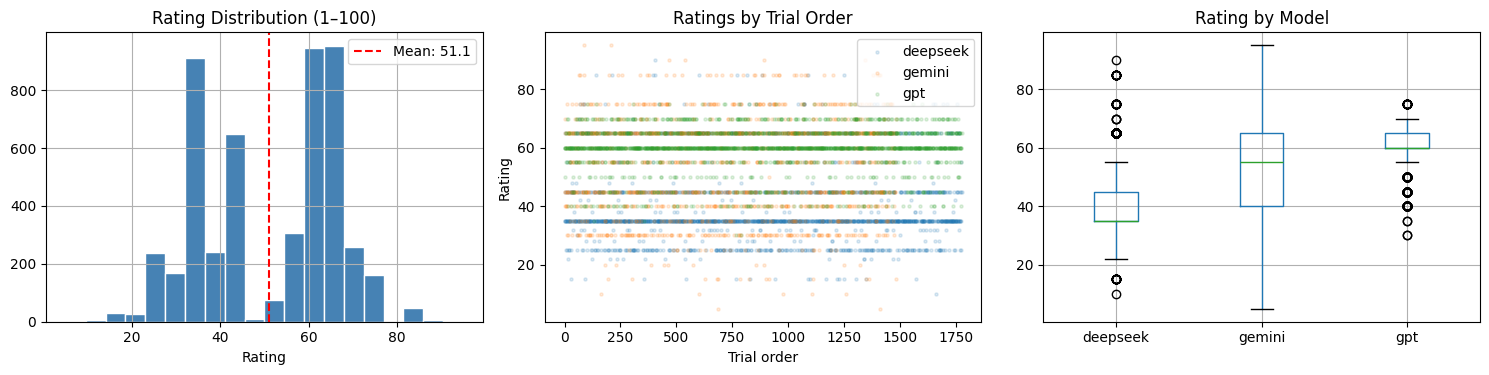

Sequential correlation by model:
  deepseek   r=-0.019, p=0.428 ✓
  gemini     r=0.017, p=0.525 ✓
  gpt        r=0.042, p=0.076 ✓


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
df['rating'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (1–100)')
axes[0].set_xlabel('Rating')
axes[0].axvline(df['rating'].mean(), color='red', ls='--',
                label=f"Mean: {df['rating'].mean():.1f}")
axes[0].legend()

# Sequential independence
for name, mdf in df.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    axes[1].scatter(range(len(mdf)), mdf['rating'], alpha=0.15, s=5, label=name)
axes[1].set_title('Ratings by Trial Order')
axes[1].set_xlabel('Trial order')
axes[1].set_ylabel('Rating')
axes[1].legend()

# Per-model boxplot
df.boxplot(column='rating', by='model', ax=axes[2])
axes[2].set_title('Rating by Model')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'quality_checks.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sequential correlation by model:")
for name, mdf in df.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    r, p = stats.pearsonr(range(len(mdf)), mdf['rating'])
    flag = " ⚠️" if p < 0.05 else " ✓"
    print(f"  {name:10s} r={r:.3f}, p={p:.3f}{flag}")

## 4. Descriptive Statistics

In [19]:
STATUS_ORDER = ['low', 'medium', 'high']

print("═══ Mean Rating by Status ═══")
print(df.groupby('status')['rating'].agg(['mean','std','count']).reindex(STATUS_ORDER).round(2))

print("\n═══ Mean Rating by Expertise ═══")
print(df.groupby('expertise')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Mean Rating by Argument Type ═══")
print(df.groupby('arg_type')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Status × Expertise ═══")
print(df.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER).round(2))

print("\n═══ Status × Argument Type ═══")
print(df.groupby(['status','arg_type'])['rating'].mean().unstack().reindex(STATUS_ORDER).round(2))

═══ Mean Rating by Status ═══
         mean    std  count
status                     
low     49.02  14.64   1702
medium  51.04  14.34    835
high    51.49  14.89   1679

═══ Mean Rating by Expertise ═══
             mean    std  count
expertise                      
irrelevant  50.77  14.92   3529
relevant    51.82  15.01   1506

═══ Mean Rating by Argument Type ═══
              mean    std  count
arg_type                        
descriptive  51.70  15.09   2551
normative    50.45  14.79   2484

═══ Status × Expertise ═══
expertise  irrelevant  relevant
status                         
low             48.81     49.64
medium          50.26     51.83
high            51.10     52.65

═══ Status × Argument Type ═══
arg_type  descriptive  normative
status                          
low             49.63      48.39
medium          51.46      50.61
high            52.44      50.50


In [20]:
# Per-model breakdown (if multiple models)
if df['model'].nunique() > 1:
    print("═══ Per-Model: Mean Rating by Status ═══")
    for name, mdf in df.groupby('model'):
        print(f"\n--- {name.upper()} ---")
        print(mdf.groupby('status')['rating'].agg(['mean','std','count']).reindex(STATUS_ORDER).round(2))

═══ Per-Model: Mean Rating by Status ═══

--- DEEPSEEK ---
         mean    std  count
status                     
low     37.97  12.12    592
medium  39.85  12.12    296
high    41.70  13.77    592

--- GEMINI ---
         mean    std  count
status                     
low     51.21  15.07    518
medium  54.40  14.54    243
high    52.98  16.26    495

--- GPT ---
         mean   std  count
status                    
low     58.14  7.84    592
medium  59.46  7.40    296
high    60.03  6.90    592


Loading: /content/drive/MyDrive/PhD/2PhD 1Paper/data/data_gpt_20260311.csv

═══ GPT: Mean Rating by Authority Label × Expertise ═══
                                                           mean   std  count
authority_label                               expertise                     
Nobel laureate in economics                   irrelevant  61.93  7.06    148
Nobel laureate in medicine                    irrelevant  61.62  7.38    148
a person I met at the airport                 irrelevant  59.66  7.44    148
a person commenting online                    irrelevant  57.30  8.21    148
colleague in economics department             irrelevant  58.57  7.99     70
                                              relevant    59.42  7.16     78
colleague in medicine department              irrelevant  59.49  7.01     78
                                              relevant    60.36  7.53     70
commercial airline pilot I met at the airport irrelevant  59.29  7.47    148
federal judge        

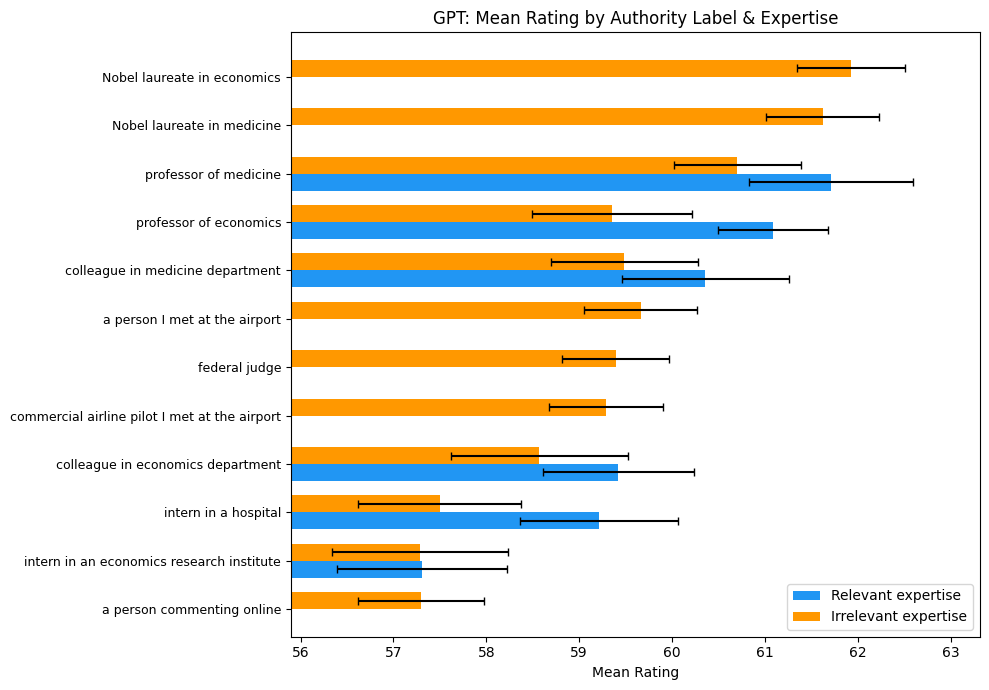

In [32]:
# ── Breakdown per authority label × expertise ──────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# ── Pick your model here ──
MODEL = "gpt"  # @param ["gpt", "deepseek", "gemini"]

# Auto-find the file for the chosen model
matches = sorted(glob.glob(DATA_PATH + f"data_{MODEL}_*.csv"))
if not matches:
    raise FileNotFoundError(f"No data file found for model '{MODEL}' in {DATA_PATH}")
filepath = matches[-1]  # latest file if multiple
print(f"Loading: {filepath}")

data = pd.read_csv(filepath)
data['status'] = data['status'].str.strip()

# ── Table: mean rating by authority_label and expertise ──
label_exp = (
    data.groupby(["authority_label", "expertise"])["rating"]
    .agg(["mean", "std", "count"])
    .round(2)
)
print(f"\n═══ {MODEL.upper()}: Mean Rating by Authority Label × Expertise ═══")
print(label_exp.to_string())

# ── Also show the marginal per label ──
label_only = (
    data.groupby("authority_label")["rating"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
    .round(2)
)
print(f"\n═══ {MODEL.upper()}: Mean Rating by Authority Label (overall) ═══")
print(label_only.to_string())

# ── Figure: grouped bar chart ──
pivot = data.groupby(["authority_label", "expertise"])["rating"].mean().unstack()
pivot_se = data.groupby(["authority_label", "expertise"])["rating"].sem().unstack()

# Sort by overall mean
order = data.groupby("authority_label")["rating"].mean().sort_values(ascending=True).index
pivot = pivot.reindex(order)
pivot_se = pivot_se.reindex(order)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(pivot))
w = 0.35

bars1 = ax.barh(x - w/2, pivot["relevant"],  w, xerr=pivot_se["relevant"],
                label="Relevant expertise",  color="#2196F3", capsize=3)
bars2 = ax.barh(x + w/2, pivot["irrelevant"], w, xerr=pivot_se["irrelevant"],
                label="Irrelevant expertise", color="#FF9800", capsize=3)

ax.set_yticks(x)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel("Mean Rating")
ax.set_title(f"{MODEL.upper()}: Mean Rating by Authority Label & Expertise")
ax.legend()

# Auto-scale x-axis to fit the data
rating_min = pivot.min().min()
rating_max = pivot.max().max()
margin = (rating_max - rating_min) * 0.3
ax.set_xlim(max(0, rating_min - margin), min(100, rating_max + margin))

plt.tight_layout()
plt.savefig(RESULTS_PATH + f"label_expertise_breakdown_{MODEL}.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Regressions

In [22]:
# Model 1: Main effects
m1 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 1: Main Effects ═══")
print(m1.summary())

═══ MODEL 1: Main Effects ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     149.2
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.86e-153
Time:                        08:29:12   Log-Likelihood:                -20654.
No. Observations:                5035   AIC:                         4.132e+04
Df Residuals:                    5028   BIC:                         4.137e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [23]:
# Model 2: Status × Argument Type interaction
m2 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(arg_type) + C(expertise)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 2: Status × Argument Type ═══")
print(m2.summary())

═══ MODEL 2: Status × Argument Type ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     90.64
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          3.37e-151
Time:                        08:29:21   Log-Likelihood:                -20653.
No. Observations:                5035   AIC:                         4.133e+04
Df Residuals:                    5024   BIC:                         4.140e+04
Df Model:                          10                                         
Covariance Type:              cluster                                         
                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

In [24]:
# Model 3: Full three-way interaction
m3 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(expertise) * C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 3: Full Three-Way ═══")
print(m3.summary())

═══ MODEL 3: Full Three-Way ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     55.23
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          7.50e-150
Time:                        08:29:28   Log-Likelihood:                -20634.
No. Observations:                5035   AIC:                         4.130e+04
Df Residuals:                    5017   BIC:                         4.142e+04
Df Model:                          17                                         
Covariance Type:              cluster                                         
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 17
  warnings.warn('covariance of constraints does not have full '


In [25]:
# Model 4: With model fixed effects (auto-activates with multiple models)
if df['model'].nunique() > 1:
    m4 = smf.ols(
        'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type) + C(model)',
        data=df
    ).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})
    print("═══ MODEL 4: Main Effects + Model FE ═══")
    print(m4.summary())
else:
    print("Single model — skipping model fixed effects.")

═══ MODEL 4: Main Effects + Model FE ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     590.1
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        08:29:36   Log-Likelihood:                -19798.
No. Observations:                5035   AIC:                         3.961e+04
Df Residuals:                    5026   BIC:                         3.967e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

## 6. Effect Sizes

In [26]:
status_eff    = df[df['status']=='high']['rating'].mean() - df[df['status']=='low']['rating'].mean()
expertise_eff = df[df['expertise']=='relevant']['rating'].mean() - df[df['expertise']=='irrelevant']['rating'].mean()
type_eff      = df[df['arg_type']=='normative']['rating'].mean() - df[df['arg_type']=='descriptive']['rating'].mean()

print(f"Status    (high − low):              {status_eff:+.2f}")
print(f"Expertise (relevant − irrelevant):   {expertise_eff:+.2f}")
print(f"Type      (normative − descriptive): {type_eff:+.2f}")

if abs(status_eff) > abs(expertise_eff):
    ratio = abs(status_eff / expertise_eff) if expertise_eff != 0 else float('inf')
    print(f"\n→ Status effect is {ratio:.1f}× larger → STATUS DOMINATES")
else:
    ratio = abs(expertise_eff / status_eff) if status_eff != 0 else float('inf')
    print(f"\n→ Expertise effect is {ratio:.1f}× larger → EXPERTISE DOMINATES")

# Cohen's d
high = df[df['status']=='high']['rating']
low  = df[df['status']=='low']['rating']
pooled_sd = np.sqrt((high.std()**2 + low.std()**2) / 2)
d = (high.mean() - low.mean()) / pooled_sd
print(f"\nCohen's d (status high vs low): {d:.3f}")

Status    (high − low):              +2.47
Expertise (relevant − irrelevant):   +1.06
Type      (normative − descriptive): -1.25

→ Status effect is 2.3× larger → STATUS DOMINATES

Cohen's d (status high vs low): 0.167


## 7. The Killer Figure

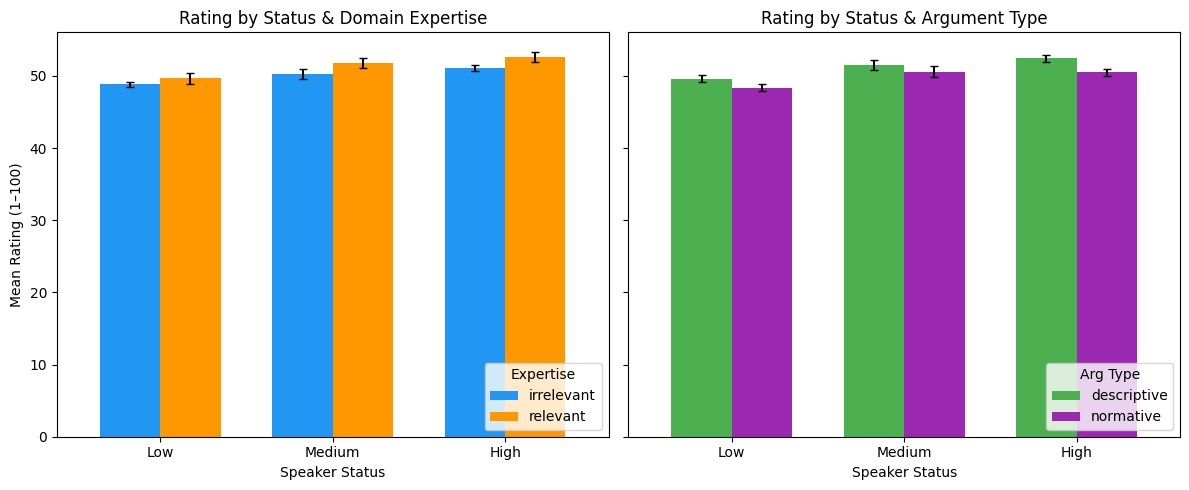

Saved to /content/drive/MyDrive/PhD/2PhD 1Paper/results/authority_bias_figure.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
STATUS_ORDER = ['low', 'medium', 'high']

# Panel A: Status × Expertise
means_a = df.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER)
sems_a  = df.groupby(['status','expertise'])['rating'].sem().unstack().reindex(STATUS_ORDER)
means_a.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800'],
             width=0.7, yerr=sems_a, capsize=3)
axes[0].set_title('Rating by Status & Domain Expertise', fontsize=12)
axes[0].set_xlabel('Speaker Status')
axes[0].set_ylabel('Mean Rating (1–100)')
axes[0].legend(title='Expertise', loc='lower right')
axes[0].set_xticklabels(['Low','Medium','High'], rotation=0)

# Panel B: Status × Argument Type
means_b = df.groupby(['status','arg_type'])['rating'].mean().unstack().reindex(STATUS_ORDER)
sems_b  = df.groupby(['status','arg_type'])['rating'].sem().unstack().reindex(STATUS_ORDER)
means_b.plot(kind='bar', ax=axes[1], color=['#4CAF50','#9C27B0'],
             width=0.7, yerr=sems_b, capsize=3)
axes[1].set_title('Rating by Status & Argument Type', fontsize=12)
axes[1].set_xlabel('Speaker Status')
axes[1].legend(title='Arg Type', loc='lower right')
axes[1].set_xticklabels(['Low','Medium','High'], rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'authority_bias_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_PATH}authority_bias_figure.png")

## 8. Weakness Length Analysis

In [28]:
df['weakness_length'] = df['weaknesses'].fillna('').str.len()

print("Mean weakness length by status:")
print(df.groupby('status')['weakness_length'].mean().reindex(STATUS_ORDER).round(1))

m_wl = smf.ols(
    'weakness_length ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})
print("\n═══ Weakness Length Regression ═══")
print(m_wl.summary())

Mean weakness length by status:
status
low       771.7
medium    798.2
high      812.3
Name: weakness_length, dtype: float64

═══ Weakness Length Regression ═══
                            OLS Regression Results                            
Dep. Variable:        weakness_length   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     114.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.14e-122
Time:                        08:30:04   Log-Likelihood:                -33036.
No. Observations:                5035   AIC:                         6.609e+04
Df Residuals:                    5028   BIC:                         6.613e+04
Df Model:                           6                                         
Covariance Type:              cluster                                         
                                                 

In [ ]:

data = pd.read_csv(DATA_PATH + "data_gpt_20260311.csv")

authority_stats = (
    data.groupby("authority_label")["rating"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

authority_stats["se"] = authority_stats["std"] / (authority_stats["count"] ** 0.5)

authority_stats = authority_stats.sort_values("mean", ascending=False)

authority_stats

,authority_label,mean,std,count,se
0,Nobel laureate in economics,61.925676,7.059602,148,0.580296
1,Nobel laureate in medicine,61.621622,7.382094,148,0.606804
11,professor of medicine,61.182432,6.735061,148,0.553619
10,professor of economics,60.270270,6.302569,148,0.518068
5,colleague in medicine department,59.898649,7.248495,148,0.595823
2,a person I met at the airport,59.662162,7.438230,148,0.611419
7,federal judge,59.391892,6.947456,148,0.571077
6,commercial airline pilot I met at the airport,59.290541,7.468987,148,0.613947
4,colleague in economics department,59.020270,7.551609,148,0.620738
8,intern in a hospital,58.310811,7.504059,148,0.616830


## 9. Export

In [ ]:
summary = df.groupby(['status','expertise','arg_type'])['rating'].agg(['mean','std','count']).round(2)
summary.to_csv(RESULTS_PATH + 'summary_table.csv')

coefs = pd.DataFrame({
    'M1_coef': m1.params.round(3), 'M1_pval': m1.pvalues.round(4),
    'M2_coef': m2.params.round(3), 'M2_pval': m2.pvalues.round(4),
})
coefs.to_csv(RESULTS_PATH + 'regression_coefficients.csv')

print(f"Saved to {RESULTS_PATH}:")
print("  summary_table.csv")
print("  regression_coefficients.csv")
print("  authority_bias_figure.png")
print("  quality_checks.png")
display(summary)

KeyError: 'label'